# Quels facteurs sont associés à la régularité des TGV en France ?

## Introduction

La ponctualité ferroviaire est un enjeu majeur pour les usagers comme pour les opérateurs de transport.  
Dans ce projet, nous exploitons les données mensuelles de régularité des TGV publiées par la SNCF afin d'étudier les facteurs associés à la régularité à l'arrivée.

Notre objectif est double :
- décrire les grandes tendances de la régularité des TGV en France ;
- identifier les variables les plus associées à cette régularité à l'aide d'une modélisation statistique.

Nous nous intéressons en particulier au rôle :
- de la ligne ;
- de la temporalité (mois, année, saison) ;
- du trafic ;
- des causes de retard.

## Chargement des bibliothèques

Nous commençons par importer les bibliothèques nécessaires à l'analyse, à la visualisation et à la modélisation.  

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Chargement des données
Nous chargeons le jeu de données portant sur la régularité mensuelle des TGV.

In [2]:
url = "https://data.sncf.com/api/explore/v2.1/catalog/datasets/regularite-mensuelle-tgv-aqst/exports/csv?delimiter=%3B&list_separator=%2C&quote_all=false&with_bom=true"
df = pd.read_csv(url, sep=";")
df.head()

,date,service,gare_depart,gare_arrivee,duree_moyenne,nb_train_prevu,nb_annulation,commentaire_annulation,nb_train_depart_retard,retard_moyen_depart,...,nb_train_retard_sup_15,retard_moyen_trains_retard_sup15,nb_train_retard_sup_30,nb_train_retard_sup_60,prct_cause_externe,prct_cause_infra,prct_cause_gestion_trafic,prct_cause_materiel_roulant,prct_cause_gestion_gare,prct_cause_prise_en_charge_voyageurs
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386


Afin de mieux comprendre la structure du jeu de données, nous examinons la liste des variables disponibles.  
Cela permet d’identifier les informations exploitables pour l’analyse, ainsi que les éventuelles transformations à effectuer.

In [3]:
df.columns.tolist()

['date',
 'service',
 'gare_depart',
 'gare_arrivee',
 'duree_moyenne',
 'nb_train_prevu',
 'nb_annulation',
 'commentaire_annulation',
 'nb_train_depart_retard',
 'retard_moyen_depart',
 'retard_moyen_tous_trains_depart',
 'commentaire_retards_depart',
 'nb_train_retard_arrivee',
 'retard_moyen_arrivee',
 'retard_moyen_tous_trains_arrivee',
 'commentaires_retard_arrivee',
 'nb_train_retard_sup_15',
 'retard_moyen_trains_retard_sup15',
 'nb_train_retard_sup_30',
 'nb_train_retard_sup_60',
 'prct_cause_externe',
 'prct_cause_infra',
 'prct_cause_gestion_trafic',
 'prct_cause_materiel_roulant',
 'prct_cause_gestion_gare',
 'prct_cause_prise_en_charge_voyageurs']

Afin de compléter cette première exploration, nous examinons le type des variables ainsi que le nombre de valeurs non nulles.  
Cela permet d’identifier les variables numériques, catégorielles, ainsi que la présence éventuelle de valeurs manquantes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11834 entries, 0 to 11833
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  11834 non-null  object 
 1   service                               11834 non-null  object 
 2   gare_depart                           11834 non-null  object 
 3   gare_arrivee                          11834 non-null  object 
 4   duree_moyenne                         11834 non-null  int64  
 5   nb_train_prevu                        11834 non-null  int64  
 6   nb_annulation                         11834 non-null  int64  
 7   commentaire_annulation                0 non-null      float64
 8   nb_train_depart_retard                11834 non-null  int64  
 9   retard_moyen_depart                   11834 non-null  float64
 10  retard_moyen_tous_trains_depart       11834 non-null  float64
 11  commentaire_ret

Le jeu de données comporte 11 834 observations et 26 variables.  
Il contient à la fois des variables catégorielles (`Service`, gares de départ et d'arrivée), des variables numériques liées au trafic et aux retards, ainsi que quelques colonnes de commentaires.

La variable `Date` est actuellement stockée sous forme de texte (`object`).  
Par ailleurs, certaines colonnes de commentaires sont entièrement ou presque entièrement vides ; elles ne seront donc pas exploitées dans un premier temps.

## Analyse des valeurs manquantes

Nous examinons la présence de valeurs manquantes dans le jeu de données afin d’identifier les variables nécessitant un traitement particulier.

In [5]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

commentaire_annulation                  100.0
commentaire_retards_depart              100.0
commentaires_retard_arrivee              94.1
gare_depart                               0.0
service                                   0.0
gare_arrivee                              0.0
nb_train_prevu                            0.0
nb_annulation                             0.0
duree_moyenne                             0.0
date                                      0.0
retard_moyen_depart                       0.0
nb_train_depart_retard                    0.0
nb_train_retard_arrivee                   0.0
retard_moyen_tous_trains_depart           0.0
retard_moyen_arrivee                      0.0
retard_moyen_tous_trains_arrivee          0.0
nb_train_retard_sup_15                    0.0
retard_moyen_trains_retard_sup15          0.0
nb_train_retard_sup_30                    0.0
nb_train_retard_sup_60                    0.0
prct_cause_externe                        0.0
prct_cause_infra                  

une étape de vérification a permis d’identifier des valeurs aberrantes dans certaines variables, notamment la présence de la valeur "0" dans la variable `gare_depart`.

Ces valeurs ne correspondant pas à des gares réelles, elles ont été interprétées comme des données manquantes et traitées en conséquence.

In [6]:
df["gare_depart"].sort_values().unique()

array(['0', 'AIX EN PROVENCE TGV', 'ANGERS SAINT LAUD', 'ANGOULEME',
       'ANNECY', 'ARRAS', 'AVIGNON TGV', 'BARCELONA', 'BELLEGARDE (AIN)',
       'BESANCON FRANCHE COMTE TGV', 'BORDEAUX ST JEAN', 'BREST',
       'CHAMBERY CHALLES LES EAUX', 'DIJON VILLE', 'DOUAI', 'DUNKERQUE',
       'FRANCFORT', 'GENEVE', 'GRENOBLE', 'ITALIE', 'LA ROCHELLE VILLE',
       'LAUSANNE', 'LAVAL', 'LE CREUSOT MONTCEAU MONTCHANIN', 'LE MANS',
       'LILLE', 'LYON PART DIEU', 'MACON LOCHE', 'MADRID',
       'MARNE LA VALLEE', 'MARSEILLE ST CHARLES', 'METZ', 'MONTPELLIER',
       'MULHOUSE VILLE', 'NANCY', 'NANTES', 'NICE VILLE', 'NIMES',
       'PARIS EST', 'PARIS LYON', 'PARIS MONTPARNASSE', 'PARIS NORD',
       'PARIS VAUGIRARD', 'PERPIGNAN', 'POITIERS', 'QUIMPER', 'REIMS',
       'RENNES', 'SAINT ETIENNE CHATEAUCREUX', 'ST MALO',
       'ST PIERRE DES CORPS', 'STRASBOURG', 'STUTTGART', 'TOULON',
       'TOULOUSE MATABIAU', 'TOURCOING', 'TOURS', 'VALENCE ALIXAN TGV',
       'VANNES', 'ZURICH'], dtype=o

In [7]:
(df["gare_depart"]=='0').sum()

np.int64(4)

In [8]:
df["gare_depart"].nunique()

60

In [9]:
(df["gare_arrivee"]=='0').sum()

np.int64(12)

In [10]:
df["gare_arrivee"].nunique()

60

In [11]:
# Nombre de lignes avant correction
nb_lignes_avant = len(df)

In [12]:
# Remplacement des valeurs aberrantes par NaN
df["gare_depart"] = df["gare_depart"].replace('0', np.nan)
df["gare_arrivee"] = df["gare_arrivee"].replace('0', np.nan)

In [13]:
# Vérification du nombre de valeurs manquantes créées
print("Valeurs manquantes dans gare_depart :", df["gare_depart"].isna().sum())
print("Valeurs manquantes dans gare_arrivee :", df["gare_arrivee"].isna().sum())

Valeurs manquantes dans gare_depart : 4
Valeurs manquantes dans gare_arrivee : 12


In [14]:

# Suppression des lignes concernées
df= df.dropna(subset=["gare_depart", "gare_arrivee"]).copy()

In [15]:
# Nombre de lignes après correction
nb_lignes_apres = len(df)

In [16]:
print("Nombre de lignes supprimées :", nb_lignes_avant - nb_lignes_apres)
print("Nouvelle dimension du jeu de données :", df.shape)

Nombre de lignes supprimées : 16
Nouvelle dimension du jeu de données : (11818, 26)



## Préparation des variables temporelles

Afin d'étudier l'évolution de la régularité dans le temps, nous convertissons d'abord la variable `Date` en véritable format date.  
Nous créons ensuite des variables temporelles plus directement exploitables, comme l'année et le mois.

In [17]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m")
df["annee"] = df["date"].dt.year

df["mois"] = df["date"].dt.month

In [18]:
df[["date", "annee", "mois"]].head()

,date,annee,mois
0,2018-01-01,2018,1
1,2018-01-01,2018,1
2,2018-01-01,2018,1
3,2018-01-01,2018,1
4,2018-01-01,2018,1


Afin de compléter les variables temporelles, nous introduisons une variable `saison`, construite à partir du mois.  
Cela permet d’analyser plus facilement les effets saisonniers sur la régularité.

In [19]:
def get_saison(mois):
    if mois in [12, 1, 2]:
        return "Hiver"
    elif mois in [3, 4, 5]:
        return "Printemps"
    elif mois in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

df["saison"] = df["mois"].apply(get_saison)
df.head()

,date,service,gare_depart,gare_arrivee,duree_moyenne,nb_train_prevu,nb_annulation,commentaire_annulation,nb_train_depart_retard,retard_moyen_depart,...,nb_train_retard_sup_60,prct_cause_externe,prct_cause_infra,prct_cause_gestion_trafic,prct_cause_materiel_roulant,prct_cause_gestion_gare,prct_cause_prise_en_charge_voyageurs,annee,mois,saison
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,2018,1,Hiver
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,Hiver
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,Hiver
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,Hiver
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,2018,1,Hiver


Nous construisons une variable `ligne` afin d'identifier chaque liaison ferroviaire.  
Elle est définie comme la combinaison de la gare de départ et de la gare d'arrivée.

Cette variable permettra d'analyser les différences de régularité entre les différentes lignes.

In [20]:
df["ligne"] = df["gare_depart"] + " → " + df["gare_arrivee"]

df[["gare_depart", "gare_arrivee", "ligne"]].head()

,gare_depart,gare_arrivee,ligne
0,BORDEAUX ST JEAN,PARIS MONTPARNASSE,BORDEAUX ST JEAN → PARIS MONTPARNASSE
1,LE MANS,PARIS MONTPARNASSE,LE MANS → PARIS MONTPARNASSE
2,PARIS MONTPARNASSE,LA ROCHELLE VILLE,PARIS MONTPARNASSE → LA ROCHELLE VILLE
3,PARIS MONTPARNASSE,NANTES,PARIS MONTPARNASSE → NANTES
4,POITIERS,PARIS MONTPARNASSE,POITIERS → PARIS MONTPARNASSE


## Construction des indicateurs de trafic et de régularité

Afin de construire une mesure pertinente de la régularité, nous distinguons les circulations prévues des circulations effectivement réalisées.

Nous définissons :
- les **circulations effectives** comme les circulations prévues moins les trains annulés ;
- le **taux d'annulation** comme la proportion de trains annulés parmi les trains prévus ;
- la **régularité à l'arrivée** comme la proportion de trains arrivés sans retard parmi les circulations effectivement réalisées.

Cette approche permet de ne pas confondre les retards et les annulations.

In [21]:
df.columns

Index(['date', 'service', 'gare_depart', 'gare_arrivee', 'duree_moyenne',
       'nb_train_prevu', 'nb_annulation', 'commentaire_annulation',
       'nb_train_depart_retard', 'retard_moyen_depart',
       'retard_moyen_tous_trains_depart', 'commentaire_retards_depart',
       'nb_train_retard_arrivee', 'retard_moyen_arrivee',
       'retard_moyen_tous_trains_arrivee', 'commentaires_retard_arrivee',
       'nb_train_retard_sup_15', 'retard_moyen_trains_retard_sup15',
       'nb_train_retard_sup_30', 'nb_train_retard_sup_60',
       'prct_cause_externe', 'prct_cause_infra', 'prct_cause_gestion_trafic',
       'prct_cause_materiel_roulant', 'prct_cause_gestion_gare',
       'prct_cause_prise_en_charge_voyageurs', 'annee', 'mois', 'saison',
       'ligne'],
      dtype='object')

In [22]:
df["circulations_effectives"] = (
    df["nb_train_prevu"] - df["nb_annulation"]
)

df["taux_annulation"] = df["nb_annulation"] / df["nb_train_prevu"]

df["regularite_arrivee"] = 1 - (
    df["nb_train_retard_arrivee"] / df["circulations_effectives"]
)

Certaines observations peuvent correspondre à des situations où aucune circulation effective n'a eu lieu, par exemple lorsque tous les trains prévus ont été annulés.  
Dans ce cas, la régularité à l'arrivée n'est pas définie. Nous excluons donc ces observations afin d'éviter des divisions par zéro et de conserver une variable cible interprétable.

In [23]:
(df["circulations_effectives"] <= 0).sum()

np.int64(73)

Nous observons que 73 lignes correspondent à des situations où le nombre de circulations effectives est nul ou négatif, soit environ 0,6 % du jeu de données.  
Ces observations restent très minoritaires. Comme la régularité à l'arrivée n'y est pas définie, nous choisissons de les exclure de l'analyse.

In [24]:
df = df[df["circulations_effectives"] > 0].copy()

In [25]:
df[[
    "circulations_effectives",
    "taux_annulation",
    "regularite_arrivee"
]].head()

,circulations_effectives,taux_annulation,regularite_arrivee
0,865,0.005747,0.830058
1,405,0.002463,0.740741
2,226,0.000000,0.915929
3,505,0.005906,0.885149
4,468,0.008475,0.809829


## Sélection et renommage des variables

Toutes les variables du jeu de données ne seront pas mobilisées dans la suite de l'analyse.  
Certaines colonnes de commentaire sont entièrement ou presque entièrement vides, tandis que d'autres variables ne seront pas retenues car elles ne sont pas directement utiles à notre problématique.

Nous procédons donc à une sélection des variables les plus pertinentes pour l'étude, ainsi qu'à un éventuel renommage afin de faciliter la lisibilité du code.

In [26]:
colonnes_utiles = [
    "date",
    "annee",
    "mois",
    "saison",
    "service",
    "gare_depart",
    "gare_arrivee",
    "duree_moyenne",
    "nb_train_prevu",
    "nb_annulation",
    "prct_cause_externe",
    "prct_cause_infra",
    "prct_cause_gestion_trafic",
    "prct_cause_materiel_roulant",
    "prct_cause_gestion_gare",
    "prct_cause_prise_en_charge_voyageurs",
    "ligne",
    "circulations_effectives",
    "taux_annulation",
    "regularite_arrivee"
]

df_analyse = df[colonnes_utiles].copy()

In [27]:
df_analyse = df_analyse.rename(columns={
    "duree_moyenne": "duree_moyenne_trajet",
    "nb_train_prevu": "circulations_prevues",
    "nb_annulation": "trains_annules",
    "prct_cause_externe": "pct_retard_causes_externes",
    "prct_cause_infra": "pct_retard_infrastructure",
    "prct_cause_gestion_trafic": "pct_retard_gestion_trafic",
    "prct_cause_materiel_roulant": "pct_retard_materiel_roulant",
    "prct_cause_gestion_gare": "pct_retard_gestion_gare_materiel",
    "prct_cause_prise_en_charge_voyageurs": "pct_retard_voyageurs"
})

In [28]:
df_analyse.head()

,date,annee,mois,saison,service,gare_depart,gare_arrivee,duree_moyenne_trajet,circulations_prevues,trains_annules,pct_retard_causes_externes,pct_retard_infrastructure,pct_retard_gestion_trafic,pct_retard_materiel_roulant,pct_retard_gestion_gare_materiel,pct_retard_voyageurs,ligne,circulations_effectives,taux_annulation,regularite_arrivee
0,2018-01-01,2018,1,Hiver,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,BORDEAUX ST JEAN → PARIS MONTPARNASSE,865,0.005747,0.830058
1,2018-01-01,2018,1,Hiver,National,LE MANS,PARIS MONTPARNASSE,56,406,1,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,LE MANS → PARIS MONTPARNASSE,405,0.002463,0.740741
2,2018-01-01,2018,1,Hiver,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,PARIS MONTPARNASSE → LA ROCHELLE VILLE,226,0.000000,0.915929
3,2018-01-01,2018,1,Hiver,National,PARIS MONTPARNASSE,NANTES,124,508,3,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,PARIS MONTPARNASSE → NANTES,505,0.005906,0.885149
4,2018-01-01,2018,1,Hiver,National,POITIERS,PARIS MONTPARNASSE,94,472,4,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,POITIERS → PARIS MONTPARNASSE,468,0.008475,0.809829


La base de travail obtenue est désormais plus lisible et mieux adaptée à l’analyse.  
Les variables ont été renommées afin de faciliter leur manipulation, et seules les informations pertinentes pour l’étude ont été conservées.

Cette base enrichie sera utilisée pour les analyses descriptives et la modélisation.

Afin de compléter cette analyse, nous représentons la distribution de la régularité à l'aide d'un histogramme.  
Cela permet de visualiser plus précisément la forme de la distribution et d’identifier d’éventuelles asymétries ou concentrations.

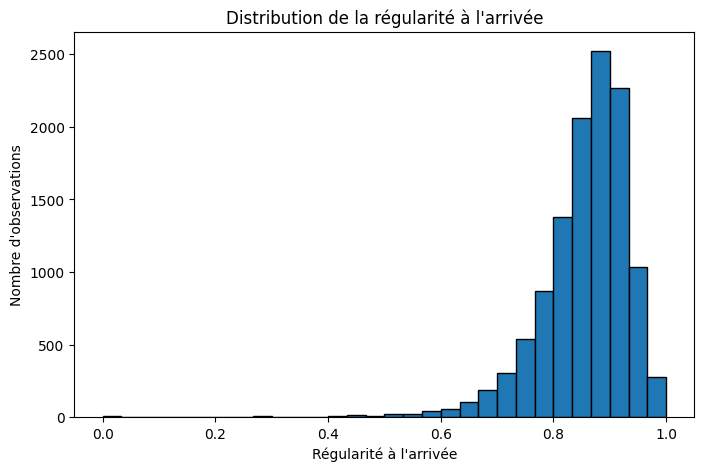

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df_analyse["regularite_arrivee"], bins=30, edgecolor="black")

plt.xlabel("Régularité à l'arrivée")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la régularité à l'arrivée")

plt.show()

La distribution de la régularité à l’arrivée est fortement concentrée sur des valeurs élevées, principalement comprises entre 0,75 et 0,95.  
Cela indique que, dans la majorité des cas, une grande proportion des trains arrive sans retard.

On observe néanmoins une certaine dispersion, avec quelques observations présentant des niveaux de régularité plus faibles.  
Ces cas plus défavorables restent minoritaires, mais suggèrent l’existence de situations particulières où la ponctualité est dégradée.

La distribution apparaît légèrement asymétrique, avec une concentration importante autour de valeurs proches de 0,85–0,90.  
Cela confirme que la régularité des TGV est globalement bonne, tout en laissant apparaître des variations qui méritent d’être expliquées.



## Évolution de la régularité dans le temps

Nous étudions maintenant l'évolution de la régularité moyenne au fil des années.  
Cette analyse permet d’identifier d’éventuelles tendances ou ruptures dans la ponctualité des TGV.

In [30]:
regularite_par_annee = (
    df_analyse.groupby("annee", as_index=False)["regularite_arrivee"]
    .mean()
)

regularite_par_annee

,annee,regularite_arrivee
0,2018,0.819562
1,2019,0.855028
2,2020,0.865765
3,2021,0.888158
4,2022,0.854645
5,2023,0.851946
6,2024,0.861360
7,2025,0.844055


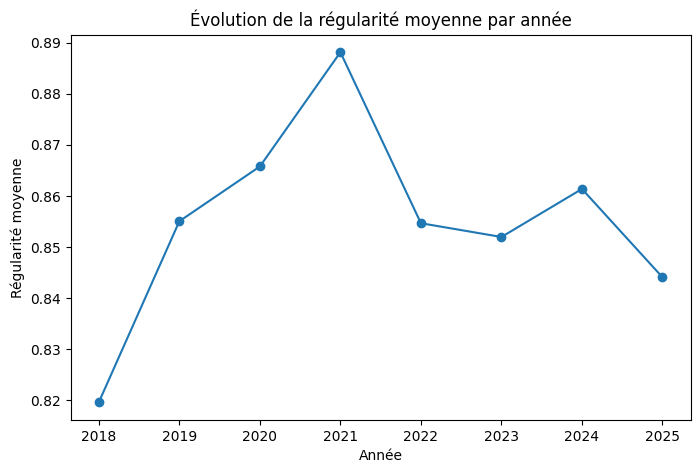

In [31]:

plt.figure(figsize=(8,5))

plt.plot(
    regularite_par_annee["annee"],
    regularite_par_annee["regularite_arrivee"],
    marker="o"
)

plt.xlabel("Année")
plt.ylabel("Régularité moyenne")
plt.title("Évolution de la régularité moyenne par année")

plt.show()

La régularité moyenne des TGV évolue au fil des années, avec des variations relativement marquées.

On observe d’abord une amélioration progressive de la régularité entre 2018 et 2021, avec un niveau maximal atteint autour de 2021.  
Cette période peut correspondre à une amélioration de l’exploitation ou à des conditions de trafic particulières.

À partir de 2021, une baisse de la régularité est observée. 
Les années suivantes montrent une certaine stabilisation, avec toutefois un niveau de régularité légèrement inférieur au pic observé avant la crise.

Ces résultats suggèrent que des facteurs conjoncturels peuvent avoir un impact significatif sur la ponctualité des TGV.

## Analyse de la saisonnalité

Nous étudions maintenant la régularité moyenne en fonction du mois, afin d’identifier d’éventuels effets saisonniers.



In [32]:
regularite_par_mois = (
    df_analyse.groupby("mois", as_index=False)["regularite_arrivee"]
    .mean()
)

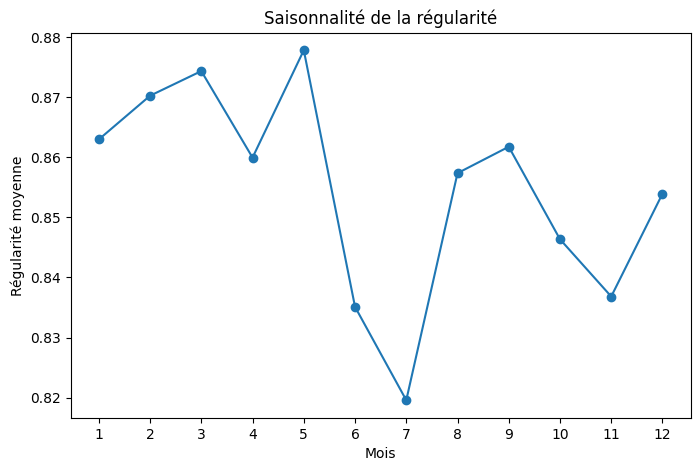

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    regularite_par_mois["mois"],
    regularite_par_mois["regularite_arrivee"],
    marker="o"
)

plt.xlabel("Mois")
plt.ylabel("Régularité moyenne")
plt.title("Saisonnalité de la régularité")

plt.xticks(range(1,13))

plt.show()

On observe une variation de la régularité selon les mois, avec un niveau relativement élevé en début d’année et au printemps.

Une forte baisse apparaît en été, notamment en juillet, ce qui peut s’expliquer par une hausse du trafic et des contraintes d’exploitation.

La régularité remonte ensuite à la rentrée, avant de fluctuer légèrement en fin d’année.

Ces résultats suggèrent l’existence d’un effet saisonnier sur la ponctualité des TGV.

## Analyse de la régularité par ligne

Nous comparons la régularité moyenne des différentes lignes ferroviaires afin d’identifier les liaisons les plus performantes ainsi que celles présentant davantage de difficultés.

In [34]:
from great_tables import GT

# Table de base unique
regularite_par_ligne = (
    df_analyse
    .groupby("ligne")
    .agg(
        regularite_moyenne=("regularite_arrivee", "mean"),
        nb_observations=("regularite_arrivee", "count")
    )
    .query("nb_observations >= 12")
    .round(3)
)

# Top 10 lignes les plus régulières
top_lignes = (
    regularite_par_ligne
    .sort_values("regularite_moyenne", ascending=False)
    .head(10)
    .reset_index()
)

# Top 10 lignes les moins régulières
bottom_lignes = (
    regularite_par_ligne
    .sort_values("regularite_moyenne", ascending=True)
    .head(10)
    .reset_index()
)

## Les lignes les plus régulières

In [35]:
GT(top_lignes).tab_header(
    title="Top 10 des lignes les plus régulières",
    subtitle="Régularité moyenne et nombre d'observations"
)


GT(_tbl_data=                                     ligne  regularite_moyenne  \
0                        PARIS EST → NANCY               0.923   
1              PARIS LYON → LYON PART DIEU               0.920   
2  BESANCON FRANCHE COMTE TGV → PARIS LYON               0.917   
3                    LAUSANNE → PARIS LYON               0.915   
4         TOURCOING → MARSEILLE ST CHARLES               0.915   
5                 RENNES → PARIS VAUGIRARD               0.914   
6               PARIS MONTPARNASSE → BREST               0.912   
7                 PARIS LYON → DIJON VILLE               0.911   
8               BREST → PARIS MONTPARNASSE               0.910   
9   PARIS MONTPARNASSE → LA ROCHELLE VILLE               0.909   

   nb_observations  
0               96  
1               96  
2               96  
3               95  
4               13  
5               12  
6               96  
7               99  
8               96  
9               95  , _body=<great_tables._gt_data.Body object at 0x7fdd026eb8c0>, _boxhead=Boxhead([ColInfo(var='ligne', type=<ColInfoTypeEnum.default: 1>, column_label='ligne', column_align='left', column_width=None), ColInfo(var='regularite_moyenne', type=<ColInfoTypeEnum.default: 1>, column_label='regularite_moyenne', column_align='right', column_width=None), ColInfo(var='nb_observations', type=<ColInfoTypeEnum.default: 1>, column_label='nb_observations', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdd026ebb60>, _spanners=Spanners([]), _heading=Heading(title='Top 10 des lignes les plus régulières', subtitle="Régularité moyenne et nombre d'observations", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdd026ebcb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdd04c88cd0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdd026ebe00>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(s

## Les lignes les moins régulières

Après avoir identifié les lignes les plus régulières, nous examinons les liaisons présentant les niveaux de régularité les plus faibles.

Cette analyse permet de repérer les lignes les plus exposées aux difficultés d’exploitation ou aux retards.

In [36]:
GT(bottom_lignes).tab_header(
    title="Top 10 des lignes les moins régulières",
    subtitle="Régularité moyenne et nombre d'observations"
)

GT(_tbl_data=                                    ligne  regularite_moyenne  nb_observations
0                     ITALIE → PARIS LYON               0.686               91
1  CHAMBERY CHALLES LES EAUX → PARIS LYON               0.731               98
2                MACON LOCHE → PARIS LYON               0.744               99
3                  LYON PART DIEU → LILLE               0.745               96
4        LYON PART DIEU → MARNE LA VALLEE               0.759               95
5                      ARRAS → PARIS NORD               0.780               96
6   LYON PART DIEU → MARSEILLE ST CHARLES               0.783               99
7            LE MANS → PARIS MONTPARNASSE               0.784               96
8            MARSEILLE ST CHARLES → LILLE               0.785               95
9                      DOUAI → PARIS NORD               0.785               96, _body=<great_tables._gt_data.Body object at 0x7fdd0232c2b0>, _boxhead=Boxhead([ColInfo(var='ligne', type=<ColInfoTypeEnum.default: 1>, column_label='ligne', column_align='left', column_width=None), ColInfo(var='regularite_moyenne', type=<ColInfoTypeEnum.default: 1>, column_label='regularite_moyenne', column_align='right', column_width=None), ColInfo(var='nb_observations', type=<ColInfoTypeEnum.default: 1>, column_label='nb_observations', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdd04c8bd90>, _spanners=Spanners([]), _heading=Heading(title='Top 10 des lignes les moins régulières', subtitle="Régularité moyenne et nombre d'observations", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdd04c882d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdd0232c510>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdd04c88910>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=

## Lien entre les causes de retard et la régularité

Nous étudions la relation entre les différentes causes de retard et la régularité à l’arrivée.

Cette analyse permet d’identifier les facteurs les plus fortement associés à une dégradation de la ponctualité.

In [37]:
variables_corr = [
    "regularite_arrivee",
    "pct_retard_causes_externes",
    "pct_retard_infrastructure",
    "pct_retard_gestion_trafic",
    "pct_retard_materiel_roulant",
    "pct_retard_gestion_gare_materiel",
    "pct_retard_voyageurs"
]

corr_matrix = df_analyse[variables_corr].corr()
corr_matrix

,regularite_arrivee,pct_retard_causes_externes,pct_retard_infrastructure,pct_retard_gestion_trafic,pct_retard_materiel_roulant,pct_retard_gestion_gare_materiel,pct_retard_voyageurs
regularite_arrivee,1.000000,-0.020494,-0.047677,-0.192379,0.130502,0.035330,0.099672
pct_retard_causes_externes,-0.020494,1.000000,-0.186907,-0.281201,-0.247561,-0.200003,-0.188952
pct_retard_infrastructure,-0.047677,-0.186907,1.000000,-0.222886,-0.238138,-0.178637,-0.164676
pct_retard_gestion_trafic,-0.192379,-0.281201,-0.222886,1.000000,-0.187239,-0.090947,-0.122937
pct_retard_materiel_roulant,0.130502,-0.247561,-0.238138,-0.187239,1.000000,0.004153,-0.103140
pct_retard_gestion_gare_materiel,0.035330,-0.200003,-0.178637,-0.090947,0.004153,1.000000,0.054943
pct_retard_voyageurs,0.099672,-0.188952,-0.164676,-0.122937,-0.103140,0.054943,1.000000


## Analyse de la régularité selon le type de service

Nous étudions si la régularité varie selon le type de service (national ou international), afin d’identifier d’éventuelles différences liées à la nature des trajets.


In [40]:
df["service"].sort_values().unique()

array(['International', 'National'], dtype=object)

In [41]:
regularite_par_service = (
    df_analyse.groupby("service")["regularite_arrivee"]
    .mean()
)

regularite_par_service

service
International    0.842215
National         0.856373
Name: regularite_arrivee, dtype: float64

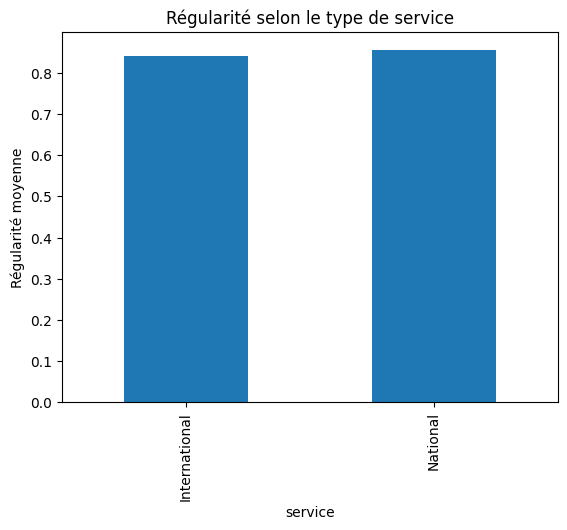

In [42]:
regularite_par_service.plot(kind="bar")

plt.ylabel("Régularité moyenne")
plt.title("Régularité selon le type de service")

plt.show()

On observe que les trajets internationaux présentent une régularité légèrement inférieure à celle des trajets nationaux.

Cet écart, bien que modéré, peut s’expliquer par une plus grande complexité opérationnelle, liée notamment aux distances plus longues, aux différences de réseaux ferroviaires et à la coordination entre plusieurs pays.

Cela suggère que le type de service constitue un facteur explicatif de la régularité, bien qu’il ne soit pas déterminant à lui seul.

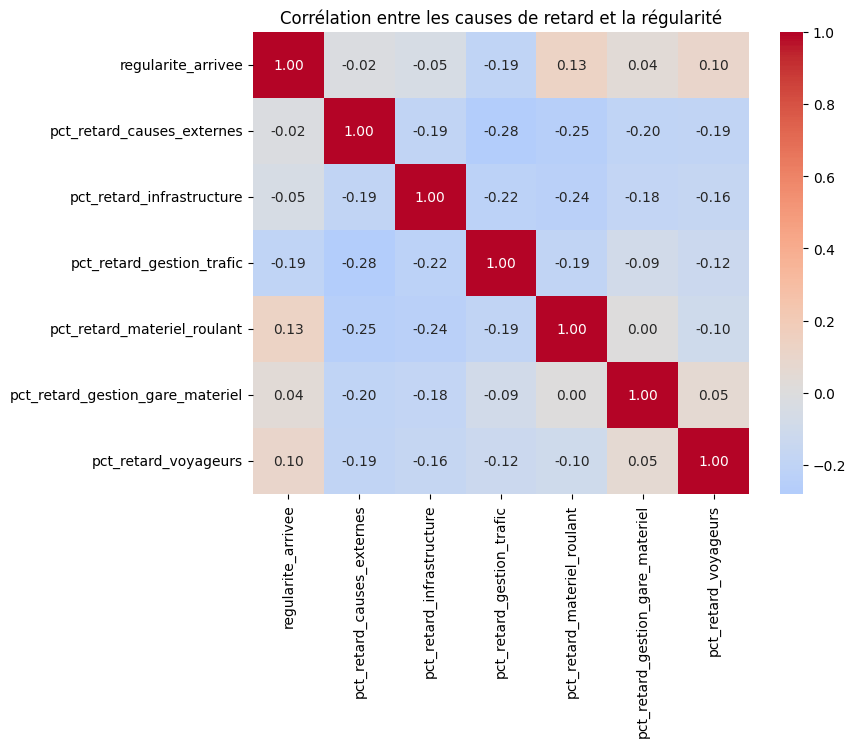

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Corrélation entre les causes de retard et la régularité")
plt.show()

Les corrélations observées entre les causes de retard et la régularité restent globalement faibles.

La gestion du trafic apparaît comme la cause la plus associée à une baisse de la régularité, bien que l’effet reste modéré.

Les autres facteurs présentent des corrélations proches de zéro, ce qui suggère qu’aucune cause isolée n’explique fortement la ponctualité des TGV.

Ces résultats indiquent que la régularité dépend probablement d’une combinaison de facteurs plutôt que d’un seul élément dominant.

## Choix du modèle

Nous avons choisi d’utiliser un modèle de type Random Forest pour la modélisation de la régularité.

Ce choix s’explique par la nature des données, qui incluent des variables complexes et potentiellement non linéaires, notamment la variable "ligne" comportant un grand nombre de modalités.

Contrairement à la régression linéaire, la Random Forest permet de mieux capturer ces relations et d’obtenir de meilleures performances prédictives.

Le modèle Random Forest est donc retenu comme modèle principal dans cette étude.

## Modélisation avec Random Forest

Nous estimons un modèle de type Random Forest afin de capturer des relations non linéaires et d’améliorer la performance prédictive.

Contrairement à la régression linéaire, ce modèle est plus flexible et peut mieux exploiter des variables complexes comme la variable "ligne".

In [51]:
X = df_analyse.drop(columns=["regularite_arrivee"])
y = df_analyse["regularite_arrivee"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
numeric_features = [
    "duree_moyenne_trajet",
    "circulations_prevues",
    "trains_annules",
    "circulations_effectives",
    "taux_annulation",
    "pct_retard_causes_externes",
    "pct_retard_infrastructure",
    "pct_retard_gestion_trafic",
    "pct_retard_materiel_roulant",
    "pct_retard_gestion_gare_materiel",
    "pct_retard_voyageurs"
]

categorical_features = [
    "service",
    "saison",
    "ligne"
]


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [55]:
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [56]:
y_pred_rf = model_rf.predict(X_test)

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² :", r2_score(y_test, y_pred_rf))

MAE : 0.0398607339129898
RMSE : 0.06409581183789308
R² : 0.4340825260983707


In [59]:
rf = model_rf.named_steps["regressor"]
feature_names = model_rf.named_steps["preprocessor"].get_feature_names_out()

importance_df = (
    pd.DataFrame({
        "variable": feature_names,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

importance_df.head(10)

,variable,importance
7,num__pct_retard_gestion_trafic,0.104635
5,num__pct_retard_causes_externes,0.093990
0,num__duree_moyenne_trajet,0.077525
9,num__pct_retard_gestion_gare_materiel,0.069904
3,num__circulations_effectives,0.069042
4,num__taux_annulation,0.065521
6,num__pct_retard_infrastructure,0.060729
10,num__pct_retard_voyageurs,0.054023
1,num__circulations_prevues,0.053273
8,num__pct_retard_materiel_roulant,0.046450


## Importance des variables

L’analyse des importances issues du modèle Random Forest met en évidence les facteurs les plus déterminants dans l’explication de la régularité des TGV.

Les variables liées aux causes de retard apparaissent comme les plus influentes, en particulier la gestion du trafic et les causes externes.

Les caractéristiques du trajet, telles que la durée moyenne et le volume de circulations, jouent également un rôle non négligeable.

Ces résultats confirment que la régularité dépend à la fois de facteurs opérationnels (gestion du trafic, organisation) et de facteurs externes (conditions extérieures, incidents), ce qui souligne la complexité du phénomène étudié.

## Conclusion

Dans ce projet, nous avons étudié les facteurs associés à la régularité des TGV en France à partir de données mensuelles publiées par la SNCF.

L’analyse descriptive a montré que la régularité est globalement élevée, mais présente des variations selon les périodes, les lignes et les conditions d’exploitation.

La modélisation par Random Forest a permis d’identifier les principaux facteurs explicatifs. Les causes de retard, notamment liées à la gestion du trafic et aux facteurs externes, apparaissent comme les plus déterminantes.

Ces résultats mettent en évidence la complexité de la ponctualité ferroviaire, qui dépend de multiples facteurs interdépendants. Ils suggèrent également que l’amélioration de la régularité passe en priorité par une meilleure gestion opérationnelle et une anticipation des aléas externes.